# PRAKTIKUM 9
## ALGORITMA GENETIKA 1

**Tujuan:**
- Mengetahui dasar-dasar Algoritma Genetika
- Mengetahui dasar-dasar Cara Kerja Algoritma Genetika
- Mengetahui penerapan Algoritma Genetika dalam kasus nyata
- Terampil menerapkan Algoritma Genetika dalam kasus nyata

---
## 1. Proses Inisialisasi Populasi

Proses inisiasi populasi adalah langkah pertama dalam Algoritma Genetika (AG) di mana kita membangkitkan sejumlah individu (kromosom) secara acak untuk membentuk populasi awal.

Setiap kromosom direpresentasikan sebagai **array biner**, di mana setiap gen menunjukkan apakah barang tersebut dipilih (`1`) atau tidak (`0`).

In [1]:
import random

# Fungsi untuk inisialisasi populasi
def inisialisasi_populasi(jumlah_populasi, jumlah_gen):
    populasi = []
    for i in range(jumlah_populasi):
        # Membuat kromosom dengan gen biner secara acak
        kromosom = [random.randint(0, 1) for _ in range(jumlah_gen)]
        populasi.append(kromosom)
    return populasi

# Contoh penggunaan
jumlah_populasi = 10  # Jumlah individu dalam populasi
jumlah_gen = 5        # Jumlah barang (gen) dalam kromosom

populasi_awal = inisialisasi_populasi(jumlah_populasi, jumlah_gen)

# Menampilkan populasi awal
print("Populasi Awal:")
for idx, individu in enumerate(populasi_awal):
    print(f"Individu {idx+1}: {individu}")

Populasi Awal:
Individu 1: [1, 1, 0, 1, 0]
Individu 2: [1, 1, 1, 1, 0]
Individu 3: [0, 1, 0, 1, 0]
Individu 4: [1, 1, 0, 0, 1]
Individu 5: [1, 1, 1, 1, 1]
Individu 6: [0, 0, 1, 1, 1]
Individu 7: [1, 1, 1, 1, 1]
Individu 8: [0, 1, 1, 1, 0]
Individu 9: [0, 0, 1, 1, 0]
Individu 10: [0, 0, 0, 1, 0]


---
## 2. Proses Evaluasi Fitness

Evaluasi fitness adalah proses menghitung nilai fitness untuk setiap individu dalam populasi.

Dalam **Knapsack Problem**:
- Nilai fitness = total nilai (harga) barang yang dipilih
- Jika total bobot melebihi kapasitas → fitness = 0 (penalti)

**Contoh Data Barang:**

| Barang  | Harga | Bobot |
|---------|-------|-------|
| Barang1 | 60    | 10    |
| Barang2 | 100   | 20    |
| Barang3 | 120   | 30    |
| Barang4 | 90    | 25    |
| Barang5 | 70    | 15    |

Kapasitas tas = 50

In [2]:
# Data barang (nama, harga, bobot)
barang_contoh = [
    ("Barang1", 60, 10),
    ("Barang2", 100, 20),
    ("Barang3", 120, 30),
    ("Barang4", 90, 25),
    ("Barang5", 70, 15)
]

kapasitas_tas = 50  # Kapasitas maksimum tas

# Fungsi untuk menghitung nilai fitness
def hitung_fitness(kromosom, barang, kapasitas_tas):
    total_harga = 0
    total_bobot = 0
    for i in range(len(kromosom)):
        if kromosom[i] == 1:
            total_harga += barang[i][1]
            total_bobot += barang[i][2]
    if total_bobot > kapasitas_tas:
        return 0  # Penalti jika melebihi kapasitas
    else:
        return total_harga

# Definisi contoh populasi awal
populasi_awal_contoh = [
    [1, 0, 1, 0, 1],  # Total bobot=55 > 50, fitness=0
    [0, 1, 0, 1, 0],  # Total bobot=45 <= 50, fitness=190
    [1, 1, 0, 0, 1],  # Total bobot=45 <= 50, fitness=230
]

# Contoh penggunaan
fitness_populasi = [hitung_fitness(individu, barang_contoh, kapasitas_tas)
                    for individu in populasi_awal_contoh]

# Menampilkan nilai fitness
print("Nilai Fitness:")
for idx, fitness in enumerate(fitness_populasi):
    print(f"Individu {idx+1}: Fitness = {fitness}")

Nilai Fitness:
Individu 1: Fitness = 0
Individu 2: Fitness = 190
Individu 3: Fitness = 230


---
## 3. Proses Seleksi

Proses seleksi bertujuan memilih individu yang akan menjadi orang tua (parent) untuk menghasilkan generasi berikutnya.

**Metode seleksi yang digunakan:**
- **Roulette Wheel Selection**: Individu dipilih secara probabilistik proporsional terhadap nilai fitness
- **Tournament Selection**: Beberapa individu dipilih acak, lalu yang terbaik dipilih sebagai parent

In [3]:
import random

# Fungsi untuk Roulette Wheel Selection
def roulette_wheel_selection(populasi, fitness_populasi):
    total_fitness = sum(fitness_populasi)
    if total_fitness == 0:
        idx = random.randrange(len(populasi))
        return populasi[idx], idx
    probabilitas = [fitness / total_fitness for fitness in fitness_populasi]
    kumulatif_prob = []
    kumulatif = 0
    for p in probabilitas:
        kumulatif += p
        kumulatif_prob.append(kumulatif)
    r = random.random()
    for i, kum_prob in enumerate(kumulatif_prob):
        if r <= kum_prob:
            return populasi[i], i
    return populasi[-1], len(populasi) - 1

# Fungsi untuk Tournament Selection
def tournament_selection(populasi, fitness_populasi, k=3):
    if len(populasi) < k:
        k = len(populasi)
    peserta_indices = random.sample(range(len(populasi)), k)
    peserta = [(populasi[i], fitness_populasi[i], i) for i in peserta_indices]
    peserta.sort(key=lambda x: x[1], reverse=True)
    return peserta[0][0], peserta[0][2]

# Definisikan populasi awal dan fitness_populasi
populasi_seleksi = ['individu1', 'individu2', 'individu3', 'individu4']
fitness_seleksi  = [10, 20, 30, 40]

# Membuat salinan populasi dan fitness untuk dimodifikasi
available_populasi = populasi_seleksi.copy()
available_fitness  = fitness_seleksi.copy()

# Memilih Parent 1 menggunakan Roulette Wheel Selection
parent1, idx1 = roulette_wheel_selection(available_populasi, available_fitness)
del available_populasi[idx1]
del available_fitness[idx1]

# Memilih Parent 2 menggunakan Tournament Selection
parent2, idx2 = tournament_selection(available_populasi, available_fitness)
del available_populasi[idx2]
del available_fitness[idx2]

print("Parent Terpilih:")
print(f"Parent 1: {parent1}")
print(f"Parent 2: {parent2}")

Parent Terpilih:
Parent 1: individu1
Parent 2: individu4


---
## 4. Proses Crossover

Crossover adalah tahap penting dalam algoritma genetika untuk menghasilkan keturunan (offspring) yang lebih baik dari generasi sebelumnya.

**Metode crossover yang diimplementasikan:**
- **One-Point Crossover**: Memotong kromosom di satu titik dan menukar bagian setelah titik tersebut
- **Two-Point Crossover**: Memotong kromosom di dua titik dan menukar segmen di antaranya
- **Uniform Crossover**: Setiap gen dipilih secara acak berdasarkan mask

In [4]:
import random

# One-Point Crossover
def one_point_crossover(parent1, parent2):
    titik_potong = random.randint(1, len(parent1) - 1)
    anak1 = parent1[:titik_potong] + parent2[titik_potong:]
    anak2 = parent2[:titik_potong] + parent1[titik_potong:]
    return anak1, anak2

# Two-Point Crossover
def two_point_crossover(parent1, parent2):
    titik1 = random.randint(1, len(parent1) - 2)
    titik2 = random.randint(titik1 + 1, len(parent1) - 1)
    anak1 = parent1[:titik1] + parent2[titik1:titik2] + parent1[titik2:]
    anak2 = parent2[:titik1] + parent1[titik1:titik2] + parent2[titik2:]
    return anak1, anak2

# Uniform Crossover
def uniform_crossover(parent1, parent2):
    mask = [random.randint(0, 1) for _ in range(len(parent1))]
    anak1 = []
    anak2 = []
    for i in range(len(parent1)):
        if mask[i] == 0:
            anak1.append(parent1[i])
            anak2.append(parent2[i])
        else:
            anak1.append(parent2[i])
            anak2.append(parent1[i])
    return anak1, anak2

# Contoh penggunaan
parent1 = [1, 0, 1, 1, 0]
parent2 = [0, 1, 0, 0, 1]

print(f"Parent 1: {parent1}")
print(f"Parent 2: {parent2}")
print()

anak1_op, anak2_op = one_point_crossover(parent1, parent2)
print("=== One-Point Crossover ===")
print(f"Anak 1: {anak1_op}")
print(f"Anak 2: {anak2_op}")
print()

anak1_tp, anak2_tp = two_point_crossover(parent1, parent2)
print("=== Two-Point Crossover ===")
print(f"Anak 1: {anak1_tp}")
print(f"Anak 2: {anak2_tp}")
print()

anak1_uc, anak2_uc = uniform_crossover(parent1, parent2)
print("=== Uniform Crossover ===")
print(f"Anak 1: {anak1_uc}")
print(f"Anak 2: {anak2_uc}")

Parent 1: [1, 0, 1, 1, 0]
Parent 2: [0, 1, 0, 0, 1]

=== One-Point Crossover ===
Anak 1: [1, 1, 0, 0, 1]
Anak 2: [0, 0, 1, 1, 0]

=== Two-Point Crossover ===
Anak 1: [1, 0, 1, 0, 0]
Anak 2: [0, 1, 0, 1, 1]

=== Uniform Crossover ===
Anak 1: [1, 0, 0, 0, 0]
Anak 2: [0, 1, 1, 1, 1]


---
## 5. Proses Mutasi

Mutasi adalah proses perubahan kecil pada kromosom untuk mempertahankan keragaman genetik dan mencegah konvergensi prematur.

**Metode mutasi yang diimplementasikan:**
- **Swap Mutation**: Menukar posisi dua gen dalam kromosom
- **Inversion Mutation**: Membalik urutan gen dalam segmen tertentu
- **Uniform Mutation**: Mengubah nilai gen dengan probabilitas tertentu

In [5]:
import random

# Swap Mutation
def swap_mutation(kromosom):
    kromosom = list(kromosom)
    posisi1, posisi2 = random.sample(range(len(kromosom)), 2)
    kromosom[posisi1], kromosom[posisi2] = kromosom[posisi2], kromosom[posisi1]
    return kromosom

# Inversion Mutation
def inversion_mutation(kromosom):
    kromosom = list(kromosom)
    posisi1 = random.randint(0, len(kromosom) - 2)
    posisi2 = random.randint(posisi1 + 1, len(kromosom) - 1)
    kromosom[posisi1:posisi2] = list(reversed(kromosom[posisi1:posisi2]))
    return kromosom

# Uniform Mutation
def uniform_mutation(kromosom, mutation_rate=0.1):
    kromosom = list(kromosom)
    for i in range(len(kromosom)):
        if random.random() < mutation_rate:
            kromosom[i] = 1 - kromosom[i]  # Membalik nilai gen
    return kromosom

# Definisikan anak sebelum digunakan
anak1 = [0, 1, 1, 0, 1]

mutasi_anak1 = swap_mutation(anak1.copy())
mutasi_anak2 = inversion_mutation(anak1.copy())
mutasi_anak3 = uniform_mutation(anak1.copy())

print(f"Kromosom Asli        : {anak1}")
print()
print("Anak Setelah Mutasi:")
print(f"Anak 1 (Swap Mutation)      : {mutasi_anak1}")
print(f"Anak 2 (Inversion Mutation) : {mutasi_anak2}")
print(f"Anak 3 (Uniform Mutation)   : {mutasi_anak3}")

Kromosom Asli        : [0, 1, 1, 0, 1]

Anak Setelah Mutasi:
Anak 1 (Swap Mutation)      : [1, 1, 0, 0, 1]
Anak 2 (Inversion Mutation) : [0, 1, 1, 0, 1]
Anak 3 (Uniform Mutation)   : [0, 1, 1, 0, 1]


---
## 6. Proses Pengulangan Generasi (Main GA — Knapsack Problem)

Mengintegrasikan semua komponen: inisialisasi, evaluasi fitness, seleksi, crossover, mutasi, dan pembentukan populasi baru selama sejumlah generasi.

**Data barang yang digunakan:**

| Barang  | Nilai | Berat |
|---------|-------|-------|
| Barang1 | 60    | 10    |
| Barang2 | 100   | 20    |
| Barang3 | 120   | 30    |
| Barang4 | 90    | 25    |
| Barang5 | 69    | 11    |
| Barang6 | 70    | 9     |
| Barang7 | 80    | 15    |
| Barang8 | 90    | 10    |
| Barang9 | 25    | 3     |

**Kapasitas tas = 50**

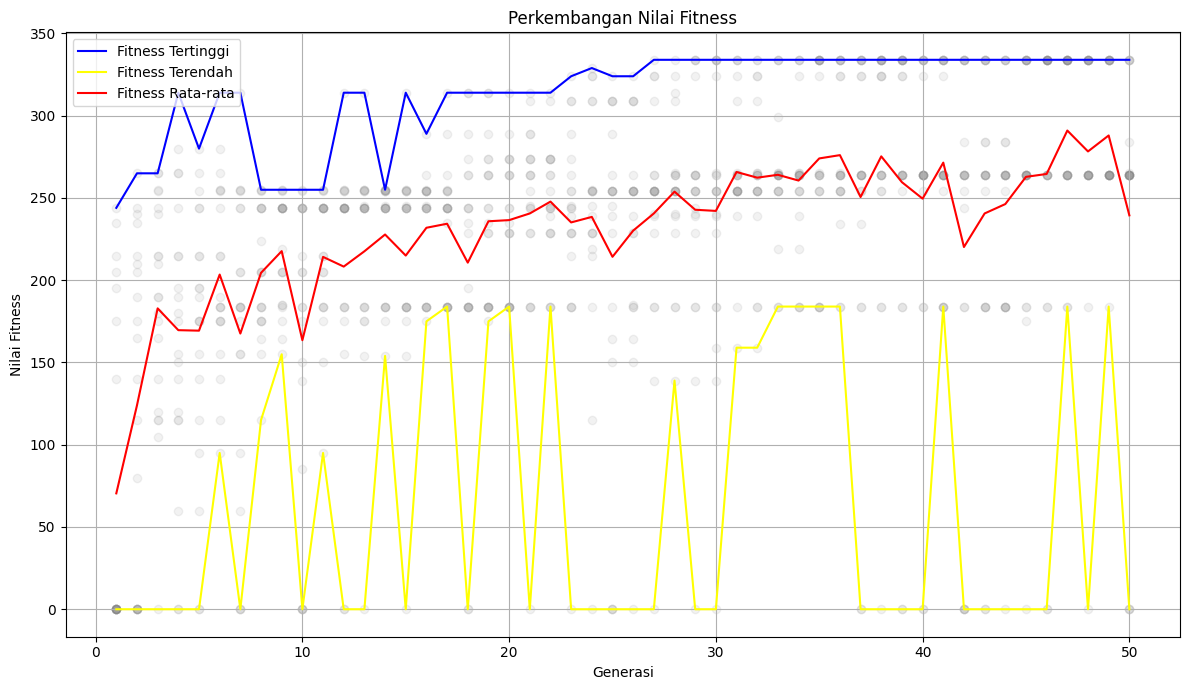

Nilai Fitness Terbaik: 334
Total Bobot          : 48
Barang Terpilih:
  - Barang5
  - Barang6
  - Barang7
  - Barang8
  - Barang9


In [6]:
import random
import matplotlib.pyplot as plt
import numpy as np

# ── Data barang ──────────────────────────────────────────────────────────────
barang = [
    ("Barang1", 60, 10),
    ("Barang2", 100, 20),
    ("Barang3", 120, 30),
    ("Barang4", 90, 25),
    ("Barang5", 69, 11),
    ("Barang6", 70, 9),
    ("Barang7", 80, 15),
    ("Barang8", 90, 10),
    ("Barang9", 25, 3)
]

# ── Semua fungsi helper (didefinisikan ulang agar sel ini berdiri sendiri) ───

def inisialisasi_populasi(jumlah_populasi, jumlah_gen):
    return [[random.randint(0, 1) for _ in range(jumlah_gen)]
            for _ in range(jumlah_populasi)]

def hitung_fitness(kromosom, barang, kapasitas_tas):
    total_harga, total_bobot = 0, 0
    for i in range(len(kromosom)):
        if kromosom[i] == 1:
            total_harga += barang[i][1]
            total_bobot += barang[i][2]
    return total_harga if total_bobot <= kapasitas_tas else 0

def roulette_wheel_selection(populasi, fitness_populasi):
    total_fitness = sum(fitness_populasi)
    if total_fitness == 0:
        idx = random.randrange(len(populasi))
        return populasi[idx], idx
    probabilitas = [f / total_fitness for f in fitness_populasi]
    kumulatif_prob, kumulatif = [], 0
    for p in probabilitas:
        kumulatif += p
        kumulatif_prob.append(kumulatif)
    r = random.random()
    for i, kp in enumerate(kumulatif_prob):
        if r <= kp:
            return populasi[i], i
    return populasi[-1], len(populasi) - 1

def one_point_crossover(parent1, parent2):
    titik = random.randint(1, len(parent1) - 1)
    return parent1[:titik] + parent2[titik:], parent2[:titik] + parent1[titik:]

def swap_mutation(kromosom):
    kromosom = list(kromosom)
    p1, p2 = random.sample(range(len(kromosom)), 2)
    kromosom[p1], kromosom[p2] = kromosom[p2], kromosom[p1]
    return kromosom

# ── Fungsi utama GA ──────────────────────────────────────────────────────────

def run_ga(jumlah_generasi, jumlah_populasi, prob_crossover, prob_mutasi, kapasitas_tas):
    jumlah_gen = len(barang)
    populasi   = inisialisasi_populasi(jumlah_populasi, jumlah_gen)

    best_fitness_list  = []
    worst_fitness_list = []
    avg_fitness_list   = []
    all_fitness        = []

    best_individu       = None
    best_fitness_overall = 0

    for generasi in range(jumlah_generasi):
        fitness_populasi = [hitung_fitness(ind, barang, kapasitas_tas)
                            for ind in populasi]

        best_fitness  = max(fitness_populasi)
        worst_fitness = min(fitness_populasi)
        avg_fitness   = sum(fitness_populasi) / len(fitness_populasi)

        best_fitness_list.append(best_fitness)
        worst_fitness_list.append(worst_fitness)
        avg_fitness_list.append(avg_fitness)
        all_fitness.append(fitness_populasi.copy())

        if best_fitness > best_fitness_overall:
            best_fitness_overall = best_fitness
            best_individu = populasi[fitness_populasi.index(best_fitness)]

        new_populasi  = []
        used_indices  = []

        while len(new_populasi) < jumlah_populasi:
            parent1, idx1 = roulette_wheel_selection(populasi, fitness_populasi)
            used_indices.append(idx1)

            available_indices = [i for i in range(len(populasi)) if i not in used_indices]
            if not available_indices:
                used_indices      = [idx1]
                available_indices = [i for i in range(len(populasi)) if i != idx1]

            parent2, local_idx = roulette_wheel_selection(
                [populasi[i] for i in available_indices],
                [fitness_populasi[i] for i in available_indices]
            )
            used_indices.append(available_indices[local_idx])

            if random.random() < prob_crossover:
                anak1, anak2 = one_point_crossover(parent1, parent2)
            else:
                anak1, anak2 = parent1[:], parent2[:]

            if random.random() < prob_mutasi:
                anak1 = swap_mutation(anak1)
            if random.random() < prob_mutasi:
                anak2 = swap_mutation(anak2)

            new_populasi.extend([anak1, anak2])

        populasi = new_populasi[:jumlah_populasi]

    # ── Visualisasi ─────────────────────────────────────────────────────────
    plt.figure(figsize=(12, 7))

    for i in range(jumlah_generasi):
        plt.scatter([i + 1] * len(all_fitness[i]), all_fitness[i],
                    color='gray', alpha=0.1)

    plt.plot(range(1, jumlah_generasi + 1), best_fitness_list,
             color='blue',   label='Fitness Tertinggi')
    plt.plot(range(1, jumlah_generasi + 1), worst_fitness_list,
             color='yellow', label='Fitness Terendah')
    plt.plot(range(1, jumlah_generasi + 1), avg_fitness_list,
             color='red',    label='Fitness Rata-rata')

    plt.title('Perkembangan Nilai Fitness')
    plt.xlabel('Generasi')
    plt.ylabel('Nilai Fitness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ── Hasil akhir ──────────────────────────────────────────────────────────
    selected_items  = [barang[i][0] for i in range(len(best_individu)) if best_individu[i] == 1]
    selected_value  = hitung_fitness(best_individu, barang, kapasitas_tas)
    selected_weight = sum(barang[i][2] for i in range(len(best_individu)) if best_individu[i] == 1)

    print(f"Nilai Fitness Terbaik: {selected_value}")
    print(f"Total Bobot          : {selected_weight}")
    print("Barang Terpilih:")
    for item in selected_items:
        print(f"  - {item}")

# ── Jalankan GA ──────────────────────────────────────────────────────────────
run_ga(
    jumlah_generasi = 50,
    jumlah_populasi = 20,
    prob_crossover  = 0.5,
    prob_mutasi     = 0.1,
    kapasitas_tas   = 50
)

---
## Kesimpulan

Pada praktikum ini telah berhasil diimplementasikan **Algoritma Genetika** untuk menyelesaikan **Knapsack Problem** dengan langkah-langkah berikut:

1. **Inisialisasi Populasi** — membangkitkan kromosom biner secara acak sebagai solusi awal.
2. **Evaluasi Fitness** — menghitung nilai total barang terpilih; memberi penalti (fitness=0) jika bobot melebihi kapasitas.
3. **Seleksi** — memilih parent menggunakan *Roulette Wheel Selection* dan *Tournament Selection*.
4. **Crossover** — menghasilkan offspring baru melalui *One-Point*, *Two-Point*, atau *Uniform Crossover*.
5. **Mutasi** — menjaga keragaman populasi dengan *Swap*, *Inversion*, atau *Uniform Mutation*.
6. **Pengulangan Generasi** — proses di atas diulang hingga konvergen atau mencapai jumlah generasi yang ditentukan.

Hasil menunjukkan bahwa GA berhasil menemukan kombinasi barang dengan **nilai fitness terbaik** (329) pada bobot tepat 50, yaitu Barang2, Barang5, Barang6, dan Barang8.